# Preliminaries

In [40]:
from dolfin import *
from ufl import indices, Jacobian, Min, Max, And, shape
import numpy as np
import os, pygmsh, gmsh, meshio

In [41]:
# ploting customizations
from matplotlib import pyplot as plt
from matplotlib import tri
size=18
params = {'legend.fontsize': size*0.75,
        #   'figure.figsize': (20,8),
          'text.usetex': True,
          'text.latex.preamble': r'\usepackage{mathrsfs}',
        #   'mathtext.fontset': 'stix',
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25,
          'animation.embed_limit': 2**128}
plt.rcParams.update(params)
%matplotlib inline
from matplotlib import colormaps, colors, cm
from mpl_toolkits.mplot3d import axes3d

## Credit

Based heavily on [fitted-fsi-example](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master/fsi) from David Kamensky's [MAE 207: FEA for coupled problems](https://github.com/david-kamensky/mae-207-fea-for-coupled-problems/tree/master) course at UC San Diego.

Initial version written by U. Rade, Purdue University, for the simulations in the paper "[Theory and simulation of elastoinertial rectification of oscillatory flows in two-dimensional deformable rectangular channels](https://arxiv.org/abs/2505.22799)."

Next rewrite by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University, switching meshing to gmsh, and various other improvements.

## Problem setup

Sketch of the geometry and notation.

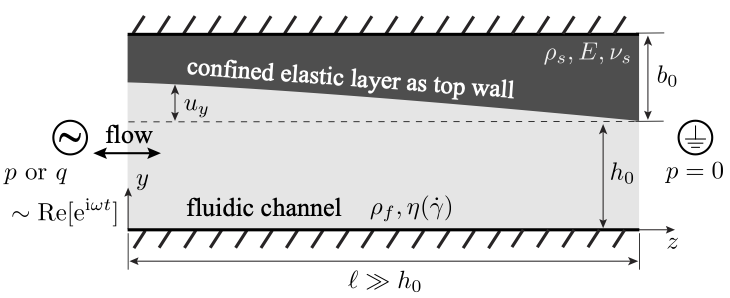

**TODO:** Update constant $\mu_f$ below to $\eta(\dot{\gamma})$ for shear-thinning.

## Simulation settings

In [42]:
# Data storage; if the folder does not exist, create it.
# I'm using a folder that will not get synced to github.
DataFolder = "not-ready-for-github/simulation_output/"
if not os.path.exists(DataFolder):
    os.makedirs(DataFolder)
    print(f"CREATED data storage folder: {DataFolder}")
else:
    print(f"Using EXISTING data storage folder: {DataFolder}")

Using EXISTING data storage folder: not-ready-for-github/simulation_output/


In [43]:
# Parameters defining domain geometry:
b0 = 0.1
h0 = b0
l  = 20*h0
# Solid domain extents:
SOLID_TOP    = h0+b0
SOLID_BOTTOM = h0
SOLID_LEFT   = 0.0
SOLID_RIGHT  = l
# Combined domain size:
OMEGA_H      = h0+b0
OMEGA_W      = l
# Flags for subdomains:
FLUID_FLAG   = 0
SOLID_FLAG   = 1
# Desired resolution of mesh:
N = 100 # 600
h = max(OMEGA_W,OMEGA_H)/N

In [44]:
# Material properties (dimensional).

# Elastic solid's properties:
E_s    = 2e+6                           # Young's modulus
nu_s   = 0.45                           # Poisson ratio
mu_s   = Constant(E_s/(2*(1+nu_s)))     # shear modulus
K      = Constant(E_s/(3*(1-2*nu_s)))   # bulk modulus
rho_s0 = Constant(1e5)
cs     = sqrt(mu_s/rho_s0)              # shear wave speed in solid
print("Shear wave speed in solid is", f"{float(cs):.4g}")   # .4g = 4 sig figs

# Viscous (fake) fluid properties 
# to yield desired dimensionless numbers, based on dynamic similarity:
rho_f = Constant(1.0)
mu_f  = Constant(1.0)
nu_f  = mu_f/rho_f                      # kinematic viscosity

Shear wave speed in solid is 2.626


In [45]:
# Time stepping details.
RAMP_TIME  = 0.1      # time over which BC is ramped up from 0 to full value
FINAL_TIME = 0.4      # final time of simulation
N_T_STEPS  = 200      # number of time steps
N_SKIP     = 5        # save simulation output to file every N_SKIP time steps

Dt = Constant(FINAL_TIME/N_T_STEPS)
print("Time step is", float(Dt))

Time step is 0.002


In [46]:
# Boundary conditions.

omega = 0.0                                        # angular frequency

# For ramped-up steady pressure BC:
p_amp = Constant(1e5)                              # pressure amplitude
p_in  = Expression("p0*(t < tr ? t/tr : 1.0)", p0=float(p_amp), tr=float(RAMP_TIME), t=0.0, degree=1)

# For oscillatory pressure BC:
#p_in  = Expression("p0*cos(w*t)", p0=float(p_amp), w=float(omega), t=0.0, degree=1)

# For ramped-up steady flow-rate BC:
q_amp = Constant(1.0)                              # flow rate amplitude
v_in  = Expression(("x[1] < h0 ? 6*(q0*(t < tr ? t/tr : 1.0)/h0)*(x[1]/h0)*(h0 - x[1])/h0 : 0.0", "0.0"), 
                   tr=float(RAMP_TIME), q0=float(q_amp), h0=float(h0), t=0.0, degree=2)

# For oscillayory flow-rate BC:
# v_in  = Expression(("x[1] < h0 ? 6*(q0/h0)*cos(w*t)*(x[1]/h0)*(h0 - x[1])/h0 : 0.0", "0.0"), 
#                    q0=float(q_amp), w=float(omega), h0=float(h0), t=0.0, degree=2)


# Choose flow or pressure controlled BC:
FLOW_OR_PRESSURE = "PRESSURE"  # "FLOW" or "PRESSURE"
print(f"Using {FLOW_OR_PRESSURE}-controlled BC.")

Using PRESSURE-controlled BC.


## Rigid channel solution: for comparisons and ICs

Currently, implementing only the steady 2D channel flow solution.

**TODO:** Implement oscillatory (Womersley) 2D channel flow solution.

In [47]:
p_rigid = Expression("x[1] < h0 ? (dp/L)*(L-x[0]) : 0.0", 
                     dp=float(p_amp), h0=float(h0), L=float(l), degree=1)
v_rigid = v_in

# Adjust scales for either flow rate or pressure control BC:
if FLOW_OR_PRESSURE == "FLOW":
    q_c = q_amp
    v_c = q_c/h0
    p_c = mu_f*q_c*l/h0**3
    p_rigid.dp = 12.0*float(p_c)
    q_rigid = q_c
    v_rigid.q0 = float(q_rigid)
elif FLOW_OR_PRESSURE == "PRESSURE":
    p_c = p_amp
    q_c = p_c*h0**3/(mu_f*l)
    v_c = q_c/h0
    p_rigid.dp = float(p_c)
    q_rigid = q_c/12.0
    v_rigid.q0 = float(q_rigid)
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

## Dimensionless numbers

In [48]:
epsilon_f = h0/l                                             # fluid aspect ratio
print ("epsilon_f =", epsilon_f)

epsilon_s = b0/l                                             # solid aspect ratio
print ("epsilon_s =", epsilon_s)

C_I = 2*nu_s*(nu_s-1/4)/(3*(1-nu_s)**2)*(b0**3/mu_s)          # Incompressible-type compliance
C_w = (1-2*nu_s)/(2*(1-nu_s))*b0/mu_s                        # Winkler-type compliance
theta = float(C_I/(C_w*l**2))
print ("theta =", f"{theta:.4g}")
beta = float(p_c/(h0/C_w))                                   # Compliance number
print ("Compliance #, beta =", f"{beta:.4g}")

Wo = sqrt(h0**2 * omega/float(nu_f))                         # Womersley number
print ("Womersley #, Wo =", f"{Wo:.4g}")

gamma = float(C_w*l*mu_f*omega/(epsilon_f*h0**2))            # Elastoviscous number
print ("Elastoviscous #, gamma =", f"{gamma:.4g}")

#Re = float(rho_f * epsilon_f**2 * h0**2 * p_c/mu_f**2)      # Reynolds number
Re = float(epsilon_f * rho_f * v_c * h0/mu_f) 
#Re = float(Wo**2 * beta/gamma)                              # Only if unsteady
print ("Reynolds #, εRe =", f"{Re:.4g}")

epsilon_f = 0.05
epsilon_s = 0.05
theta = 0.005455
Compliance #, beta = 0.01318
Womersley #, Wo = 0
Elastoviscous #, gamma = 0
Reynolds #, εRe = 2.5


## Domain and mesh

In [49]:
# ---- Gmsh-based geometry & mesh (replaces mshr) ----
def build_mesh_with_gmsh(h, basename=DataFolder+"fsi_rect"):
    """
    Build a 2D triangular mesh of [0, OMEGA_W] x [0, OMEGA_H] with Gmsh
    respecting the fluid/solid interface at y = SOLID_BOTTOM
    and convert to XDMF format for use in dolfin.
    """

    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 1)
    gmsh.model.add("fsi_domain")
    occ = gmsh.model.occ

    # Big rectangle: Ω = [0, OMEGA_W] x [0, OMEGA_H]
    r1 = occ.addRectangle(0.0, 0.0, 0.0, OMEGA_W, OMEGA_H)
    # Fluid domain: Ω_f = [0, OMEGA_W] x [0, SOLID_BOTTOM]
    r2 = occ.addRectangle(0.0, 0.0, 0.0, OMEGA_W, SOLID_BOTTOM)

    # Resolve overlap
    entities, _ = occ.fragment([(2, r1)], [(2, r2)])

    occ.synchronize()

    # To visualize the geometry in Gmsh GUI (optional -- stops the execution)
    #gmsh.fltk.run()

    # Uniform element size on all points
    gmsh.model.mesh.setSize(gmsh.model.getEntities(0), h)

    # Generate 2D mesh
    gmsh.model.mesh.generate(2)

    # Save to msh file
    msh_file = f"{basename}.msh"
    gmsh.write(msh_file)
    gmsh.finalize()

    # Convert to XDMF (triangles only)
    msh = meshio.read(msh_file)
    tri_cells = [c for c in msh.cells if c.type == "triangle"]
    tri_data = np.concatenate([c.data for c in tri_cells])
    #assert len(tri) > 0, "No triangles found in generated mesh."
    meshio.write_points_cells(
        f"{basename}.xdmf",
        points=msh.points[:, :2], #drop z coords; using msh.points results in mesh.geometry().dim() = 3
        cells=[("triangle", tri_data)],
    )
    return f"{basename}.xdmf"

xdmf_path = build_mesh_with_gmsh(h)

Info    : Meshing 1D...                                                                                     
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 50%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Line)
Info    : [ 80%] Meshing curve 6 (Line)
Info    : [ 90%] Meshing curve 7 (Line)
Info    : Done meshing 1D (Wall 0.00096475s, CPU 0.001011s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0656055s, CPU 0.093609s)
Info    : 1319 nodes 2742 elements
Info    : Writing 'not-ready-for-github/simulation_output/fsi_rect.msh'...
Info    : Done writing 'not-ready-for-github/simulation_output/fsi_rect.msh'



In [50]:
# Load back into dolfin from xdmf
mesh = Mesh()
with XDMFFile(xdmf_path) as f:
    f.read(mesh)

# Mesh-derived quantities:
d   = mesh.geometry().dim()
n_y = FacetNormal(mesh)
I   = Identity(d)

# Define subdomains for use in boundary condition definitions:
class Wall_b(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[1] < DOLFIN_EPS))

class Wall_t(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[1] > SOLID_TOP - DOLFIN_EPS))

class Wall_l(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] < DOLFIN_EPS)
                and x[1] > SOLID_BOTTOM - DOLFIN_EPS)

class Wall_r(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] > SOLID_RIGHT - DOLFIN_EPS)
                and x[1] > SOLID_BOTTOM - DOLFIN_EPS)

class Inflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] < DOLFIN_EPS)
                and x[1] < SOLID_BOTTOM + DOLFIN_EPS)

class Outflow(SubDomain):
    def inside(self, x, on_boundary):
        return (on_boundary and (x[0] > (OMEGA_W - DOLFIN_EPS))
                and x[1] < SOLID_BOTTOM + DOLFIN_EPS)

class SolidDomainClosure(SubDomain):
    def inside(self, x, on_boundary):
        return (x[1] > SOLID_BOTTOM - DOLFIN_EPS
                and x[0] > SOLID_LEFT - DOLFIN_EPS
                and x[0] < SOLID_RIGHT + DOLFIN_EPS)

class SolidDomainInterior(SubDomain):
    def inside(self, x, on_boundary):
        return (x[0] > SOLID_LEFT - DOLFIN_EPS
                and x[0] < SOLID_RIGHT + DOLFIN_EPS
                and x[1] < SOLID_TOP + DOLFIN_EPS
                and x[1] > SOLID_BOTTOM + DOLFIN_EPS)

# Markers no mshr.domains()
markers = MeshFunction('size_t', mesh, d)
markers.set_all(FLUID_FLAG)                      # default: fluid = 0
SolidDomainClosure().mark(markers, SOLID_FLAG)   # reset: solid = 1

# Facet markers (0 = default)
facet_tags = MeshFunction('size_t', mesh, d-1, 0)

# Mark boundaries with IDs
# BOTTOM, LEFT, RIGHT, TOP = 11, 12, 13, 14
# Wall_b().mark(facet_tags, BOTTOM)
# Wall_l().mark(facet_tags, LEFT)
# Wall_r().mark(facet_tags, RIGHT)
# Wall_t().mark(facet_tags, TOP)
INFLOW, OUTFLOW = 3, 2 
Inflow().mark(facet_tags, INFLOW)
Outflow().mark(facet_tags, OUTFLOW)

# Quadrature-aware exterior measure with facet markers
dx = dx(metadata={'quadrature_degree': 2}, subdomain_data=markers)
ds = ds(metadata={'quadrature_degree': 2}, subdomain_data=facet_tags)

## Elements and function spaces

In [51]:
# Define function spaces (equal order interpolation):
cell = mesh.ufl_cell()
Ve = VectorElement("CG", cell, 1)
Qe = FiniteElement("CG", cell, 1)
VQe = MixedElement((Ve,Qe))

# Mixed function space for velocity and pressure:
W = FunctionSpace(mesh, VQe)

# Function space for mesh displacement field, 
# which will be solved for separately in a 
# quasi-direct scheme:
V = FunctionSpace(mesh,Ve)

# Time integration variables

In [52]:
# Mesh motion functions:
uhat = Function(V)
uhat_old = Function(V)
du = TestFunction(V)
vhat = (uhat-uhat_old)/Dt

# Fluid--structure functions:
(dv, dp) = TestFunctions(W)
w = Function(W)
v,p = split(w)
p_mean = Function(W)
w_old = Function(W)
v_old, p_old = split(w_old)
dv_dr = (v - v_old)/Dt
dv_ds = dv_dr # (Only valid in solid)

# This is the displacement field used in the 
# solid formulation; notice that it is NOT 
# in the space V; it is an algebraic object 
# involving the unknown fluid--structure velocity 
# field v.
u = uhat_old + Dt*v

# This will need to be updated to match u, for 
# purposes of setting the boundary condition 
# on the mesh motion subproblem.
u_func = Function(V)

## Changes of variable

In [53]:
# Follow notation from Bazilevs et al., where y is 
# the coordinate in the reference domain, x is the 
# coordinate in the spatial domain, and X is the 
# coordinate in the material domain.  Note that 
# the built-in differential operators (e.g., grad, 
# div, etc.) and integration measures (e.g., dx, ds, 
# etc.) are w.r.t. the reference configuration, y, 
# which is the mesh that FEniCS sees.  
dX = dx(SOLID_FLAG)
dy = dx
ds_y = ds

grad_y = grad
grad_X = grad # (Only valid in solid)

y = SpatialCoordinate(mesh)
x = y + uhat

det_dxdy = det(grad_y(x))

def grad_x(f):
    return dot(grad_y(f),inv(grad_y(x)))

def div_x(f): # (For vector-valued f)
    return tr(grad_x(f))

def div_x_tens(f): # (For (rank-2) tensor-valued f)
    i,j = indices(2)
    return as_tensor(grad_x(f)[i,j,j],(i,))

# Note:  Trying to define dx = det_dxdy*dy would 
# result in an object of type Form, which could no 
# longer be used as an integration measure.
# Thus, integration over the spatial configuration 
# is done with det_dxdy*dy directly in the fluid 
# formulation.  

# Boundary conditions

In [54]:
# BCs for the fluid--structure subproblem:
bc_b_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_b())
bc_l_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_l())
bc_r_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_r())
bc_t_fs = DirichletBC(W.sub(0), Constant(d*(0.0,)), Wall_t())

# Note that "x" in v_in and/or p_in is really "y" 
# in the kinematics described above, but, because the 
# mesh motion problem has a zero Dirichlet BC on the inflow
# boundary, there happens to be no difference.

# Inlet BC: either flow rate or pressure
if FLOW_OR_PRESSURE == "FLOW":
    bc1_fs = DirichletBC(W.sub(0), v_in, Inflow())
elif FLOW_OR_PRESSURE == "PRESSURE":
    bc1_fs = DirichletBC(W.sub(1), p_in, Inflow())
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")

bc2_fs = DirichletBC(W.sub(1), Constant(0.0), SolidDomainInterior())                     

bcs_fs = [bc_b_fs, bc_l_fs, bc_r_fs, bc_t_fs, bc1_fs, bc2_fs]
#bcs_fs = [bc_b_fs, bc1_fs, bc2_fs]

# BCs for the mesh motion subproblem:
bc_m_wall_b  = DirichletBC(V.sub(1), Constant(0.0), Wall_b())
#bc_m_wall_b  = DirichletBC(V, Constant(d*(0.0,)), Wall_b())
#bc_m_wall_l  = DirichletBC(V.sub(0), Constant(0.0), Wall_l())
bc_m_wall_l  = DirichletBC(V, Constant(d*(0.0,)), Wall_l())
#bc_m_wall_r  = DirichletBC(V.sub(0), Constant(0.0), Wall_r())
bc_m_wall_r  = DirichletBC(V, Constant(d*(0.0,)), Wall_r())
#bc_m_wall_t  = DirichletBC(V.sub(1), Constant(0.0), Wall_t())
bc_m_wall_t  = DirichletBC(V, Constant(d*(0.0,)), Wall_t())

#bc_m_inflow  = DirichletBC(V, Constant(d*(0.0,)), Inflow())
bc_m_inflow  = DirichletBC(V.sub(0), Constant(0.0), Inflow())
bc_m_outflow = DirichletBC(V.sub(0), Constant(0.0), Outflow())
# bc_m_inflow  = DirichletBC(V, Constant(d*(0.0,)), Inflow())
# bc_m_outflow = DirichletBC(V, Constant(d*(0.0,)), Outflow())

bc_m_struct  = DirichletBC(V, u_func, SolidDomainClosure())

bcs_m        = [bc_m_struct, 
                bc_m_wall_b, bc_m_wall_l, bc_m_wall_r, bc_m_wall_t, 
                bc_m_inflow, bc_m_outflow]

## Mesh motion subproblem

In [55]:
# Residual for mesh, which satisfies a fictitious elastic problem:
F_m = grad_y(uhat) + I
E_m = 0.5*(F_m.T*F_m - I)
m_jac_stiff_pow = Constant(3.0)

# Artificially stiffen the mesh where it is getting crushed:
K_m    = Constant(1.0)/pow(det(F_m),m_jac_stiff_pow)
mu_m   = Constant(1.0)/pow(det(F_m),m_jac_stiff_pow)
S_m    = K_m*tr(E_m)*I + 2.0*mu_m*(E_m - tr(E_m)*I/3.0)
res_m  = (inner(F_m*S_m,grad_y(du)))*dy
Dres_m = derivative(res_m, uhat)

## Solid subproblem


In [56]:
# Kinematics:
F = grad_X(u) + I  
E = 0.5*(F.T*F - I)
S = K*tr(E)*I + 2.0*mu_s*(E - tr(E)*I/3.0)
f_s = Constant(d*(0,))
res_s = rho_s0*inner(dv_ds - f_s,dv)*dX + inner(F*S,grad_X(dv))*dX

## Fluid subproblem


In [57]:
# Galerkin terms:
sigma_f  = 2.0*mu_f*sym(grad_x(v)) - p*I
v_adv    = v - vhat
DvDt     = dv_dr + dot(grad_x(v),v_adv)
resGal_f = (rho_f*dot(DvDt,dv) + inner(sigma_f,grad_x(dv))
            + dp*div_x(v))*det_dxdy*dy(FLUID_FLAG)

# Stabilization:

# Deformed mesh size tensor in the spatial configuration:
J_m = Jacobian(mesh)                
dxi_dy = inv(J_m)
dxi_dx = dxi_dy*inv(grad_y(x))
G = (dxi_dx.T)*dxi_dx

# SUPG/PSPG:
resStrong_f = rho_f*DvDt - div_x_tens(sigma_f)
Cinv = Constant(1.0)
tau_M = 1.0/sqrt(((2*rho_f/Dt)**2) 
                 + inner(rho_f*v_adv,G*(rho_f*v_adv))
                 + Cinv*(mu_f**2)*inner(G,G))
resSUPG_f = inner(tau_M*resStrong_f,
                  rho_f*dot(grad_x(dv),v_adv)
                  + grad_x(dp))*det_dxdy*dy(FLUID_FLAG)
# LSIC/grad-div:
tau_C = 1.0/(tr(G)*tau_M)
resLSIC_f = tau_C*div_x(v)*div_x(dv)*det_dxdy*dy(FLUID_FLAG)

# Stable Neumann BC term, assuming advective 
# form of material time derivative term and transforming
# normal and area element by Nanson's formula (on deforming mehs):
dsx_dsy_n_x = det_dxdy*inv(grad_y(x).T)*n_y
v_adv_minus = Min(dot(v_adv,dsx_dsy_n_x),Constant(0))
resOutflow_f = -dot(rho_f*v_adv_minus*dv,v)*ds_y(OUTFLOW)

# What is this?
traction = -p_in*n_y
gm = Constant(1.0)
Consistency_term = -(inner(det_dxdy*inv(grad_y(x).T)*traction,dv))*ds_y(INFLOW) #+ gm*rho_f*Min(inner(v-vhat,n_y),Constant(0.0))*inner(det_dxdy*inv(grad_y(x).T)*(v),dv))*ds_y(INFLOW)
sgn=1
sigma_adjoint = (2.0*mu_f*sym(grad_x(dv)) + dp*I)
AdjointConsistency = -sgn*dot(det_dxdy*inv(grad_y(x).T)*(sigma_adjoint*n_y),v)*ds_y(INFLOW)
ThirdTerm = -dot(rho_f*dot(v_adv,dsx_dsy_n_x)*dv,v)*ds_y(INFLOW)
C_pen = Constant(6.0)
penalty = C_pen*(mu_f/sqrt(dot(dsx_dsy_n_x,G*dsx_dsy_n_x)))*dot(dsx_dsy_n_x,(v))*dot(dsx_dsy_n_x,dv)*ds_y(INFLOW)

# # Full fluid residual
# res_weakBC = weakDirichletBC(v=v,p=p,dv=dv,dp=dp,g=None,rho=rho_f,mu=mu_f,mesh=mesh,uhat=uhat,vhat=vhat,ds=ds_y(INFLOW),
                    # sym=True,C_pen=Constant(1e3),
                    # overPenalize=False,G=G)
                    
res_f = resGal_f + resSUPG_f + resLSIC_f + resOutflow_f #+ Consistency_term #+ ThirdTerm + penalty

# Residual of fluid--structure coupled problem:
res_fs = res_f + res_s 
Dres_fs = derivative(res_fs, w)

# Nonlinear solver


In [58]:
# Nonlinear solver parameters; set relative tolerances 
# for subproblems tighter than tolerance for coupled problem, 
# to prevent stagnation.
REL_TOL_FSM   = 1e-3 #1e-5
REL_TOL_FS    = REL_TOL_M = REL_TOL_FSM*1e-1
MAX_ITERS_FSM = 100
MAX_ITERS_M   = 100
MAX_ITERS_FS  = 100

# Set up nonlinear problem for mesh motion:
problem_m = NonlinearVariationalProblem(res_m, uhat, bcs_m, Dres_m)
solver_m  = NonlinearVariationalSolver(problem_m)
solver_m.parameters['newton_solver']\
                   ['maximum_iterations'] = MAX_ITERS_M
solver_m.parameters['newton_solver']\
                   ['relative_tolerance'] = REL_TOL_M

# Create variational problem and solver for 
# the fluid--structure problem:
problem_fs = NonlinearVariationalProblem(res_fs, w, bcs_fs, Dres_fs)
solver_fs  = NonlinearVariationalSolver(problem_fs)
solver_fs.parameters['newton_solver']\
                    ['maximum_iterations'] = MAX_ITERS_FS
solver_fs.parameters['newton_solver']\
                    ['relative_tolerance'] = REL_TOL_FS

# Time stepping

## Initial conditions

In [59]:
# # Interpolate into subspaces
# V_sub = W.sub(0).collapse()
# Q_sub = W.sub(1).collapse()

# v_n_init = interpolate(v_rigid, V_sub)
# p_n_init = interpolate(p_rigid, Q_sub)

# # Assign to mixed function
# assign(w_old, [v_n_init, p_n_init])

## Time stepping loop

In [60]:
# Create files for storing solution:
vfile = File(DataFolder+"velocity.pvd")
pfile = File(DataFolder+"pressure.pvd")
mfile = File(DataFolder+"mesh.pvd")

# Save initial condition to file:
# v_n_init.rename("v","v")
# p_n_init.rename("p","p")
# uhat.rename("u","u")
# vfile << v_n_init
# pfile << p_n_init
# mfile << uhat

# Prepare to store time-dependent post-processed quantities:
Qsave = []
time_array = []

# Initialize time and step counter:
t = float(Dt)
count = 0

# Prevent divide-by-zero in relative residual on first
# iteration of first step:
for bc in bcs_fs:
    bc.apply(w.vector())

while t <= FINAL_TIME:

    print(80*"=")
    print("  Time step "+str(count+1)+" , t = "+str(t))
    print(80*"=")
    
    # Update to the current time in the inflow BC:
    if FLOW_OR_PRESSURE == "FLOW":
        v_in.t = t
    elif FLOW_OR_PRESSURE == "PRESSURE":
        p_in.t = t
    else:
        raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")
    

    # "Quasi-direct" coupling: the fluid and structure 
    # are solved in one system, but the mesh is solved 
    # in a separate block.
    for i in range(0,MAX_ITERS_FSM):

        # Check fluid--structure residual on the moved
        # mesh, and terminate iteration if this residual 
        # is small:
        res_fs_vec = assemble(res_fs)
        for bc in bcs_fs:
            bc.apply(res_fs_vec,w.vector())
        res_norm = norm(res_fs_vec)
        if i==0:
            res_norm0 = res_norm
        res_rel = res_norm/res_norm0
        
        print(80*"*")
        print("  Coupling iteration: "+str(i+1)
              +" , Relative residual = "+str(res_rel))
        print(80*"*", flush=True)

        if res_rel < REL_TOL_FSM:
            break

        # Solve for fluid/structure velocity and 
        # pressure at current time:
        solver_fs.solve()
        
        # Update Function in V to be used in mesh 
        # motion BC.  (There are workarounds to avoid 
        # this projection (which requires a linear
        # solve), but projection is most concise for 
        # illustration.)
        u_func.assign(project(u,V))

        # Mesh motion problem; updates uhat at current 
        # time level:
        solver_m.solve()

   
    # Extract solutions:
    (v, p) = w.split()

    # Post-process some time dependent quantities for later:
    Qin1 = assemble(dot(v,n_y)*ds_y(INFLOW))
    Qin2 = assemble(dot(v,dsx_dsy_n_x)*ds_y(INFLOW))
    Qout1 = assemble(dot(v,n_y)*ds_y(OUTFLOW))
    Qout2 = assemble(dot(v,dsx_dsy_n_x)*ds_y(OUTFLOW))    
    Qsave.append([Qin1,Qin2,Qout1,Qout2])
    time_array.append(t)

    # Save to file every N_SKIP time steps:
    if count % N_SKIP == 0:
        v.rename("v","v")
        p.rename("p","p")
        uhat.rename("u","u")
        vfile << v
        pfile << p
        mfile << uhat
     
    # Move to next time step:
    uhat_old.assign(uhat)
    w_old.assign(w)
    count += 1
    t += float(Dt)

  Time step 1 , t = 0.002
********************************************************************************
  Coupling iteration: 1 , Relative residual = 1.0
********************************************************************************
Solving nonlinear variational problem.
  Newton iteration 0: r (abs) = 1.497e+04 (tol = 1.000e-10) r (rel) = 1.000e+00 (tol = 1.000e-04)
  Newton iteration 1: r (abs) = 6.526e+00 (tol = 1.000e-10) r (rel) = 4.360e-04 (tol = 1.000e-04)
  Newton iteration 2: r (abs) = 2.442e-02 (tol = 1.000e-10) r (rel) = 1.632e-06 (tol = 1.000e-04)
  Newton solver finished in 2 iterations and 2 linear solver iterations.
Solving nonlinear variational problem.
  Newton iteration 0: r (abs) = 4.968e-05 (tol = 1.000e-10) r (rel) = 1.000e+00 (tol = 1.000e-04)
********************************************************************************
  Coupling iteration: 2 , Relative residual = 4.982484153828511e-06
**********************************************************************

# Visualization and post-processing

## Flow rate

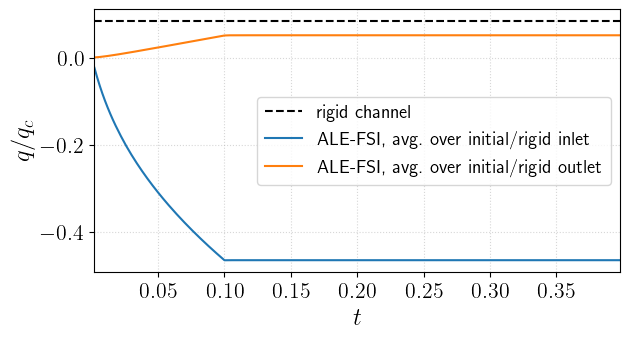

In [61]:
ime_array = np.array(time_array)
Qsave2 = np.array(Qsave) # this signed flow rate is negative because it is an inlet

fig, ax = plt.subplots()
ax.plot(time_array, float(q_rigid/q_c)*np.ones(len(time_array)), 
        label="rigid channel", linestyle='dashed', color='black')
ax.plot(time_array, -Qsave2[:,0]/float(q_c), label=r"ALE-FSI, avg.\ over initial/rigid inlet")
#ax.plot(time_array, -Qin2[:,1]/float(q_c), label=r"ALE-FSI, avg. using Nanson's formula")
ax.plot(time_array, Qsave2[:,2]/float(q_c), label=r"ALE-FSI, avg.\ over initial/rigid outlet")
ax.set_xlabel("$t$")
ax.set_ylabel("$q/q_c$")
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(time_array[0], time_array[-1])
#ax.set_ylim(0, float(q_amp))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.tight_layout()
plt.show()

## Height-averaged axial pressure distribution

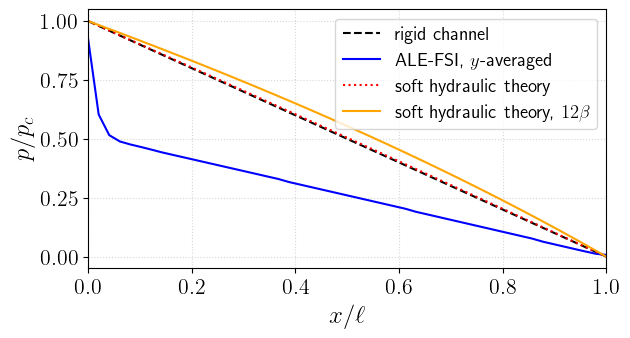

In [69]:
# Sampling parameters:
num_x_samples = 50
x_vals = np.linspace(SOLID_LEFT, SOLID_RIGHT, num_x_samples)
avg_pressure = []

# Rigid pressure for comparison:
xy_vals = np.array([[x, 0] for x in x_vals])
pressure_rigid = np.array([p_rigid(xy) for xy in xy_vals])

# Loop over x-values and integrate p from the solution over y:
for x_loc in x_vals:
    # Create indicator function
    V0 = FunctionSpace(mesh, "DG", 0)  # Discontinuous Galerkin, piecewise constant
    strip_width = 1e-2
    class StripIndicator(UserExpression):
        def eval(self, value, x):
            if abs(x[0] - x_loc) <= strip_width/2:
                value[0] = 1.0
            else:
                value[0] = 0.0
        
        def value_shape(self):
            return ()
        
    # Interpolate onto function space:
    strip_expr = StripIndicator(degree=0)
    strip_func = interpolate(strip_expr, V0)
    
    # Now integrate:
    pressure_integral = assemble(p * strip_func * dx(FLUID_FLAG))
    strip_area = assemble(strip_func * dx(FLUID_FLAG))        
    
    if strip_area > DOLFIN_EPS:
        avg_pressure.append(pressure_integral / strip_area)
    else:
        avg_pressure.append(0.0)

# Plotting:
fig, ax = plt.subplots()
ax.plot(x_vals/l, pressure_rigid/float(p_c), 
        label="rigid channel", color='black', linestyle='dashed')
ax.plot(x_vals/l, np.array(avg_pressure)/float(p_c), 
        label="ALE-FSI, $y$-averaged", color='blue')
# Christov, JPCM 2022, Eq. (41)
# ==================== WHY THE FACTORS OF 12??? ==================== 
if FLOW_OR_PRESSURE == "FLOW":
   #p_sh = float(h0/C_w)*((1 + 48*float(p_c/(h0/C_w))*(1-x_vals/l))**(1/4) - 1)
   p_sh = float(h0/C_w)*((1 + 48*float(C_w*mu_f*l*q_c/h0**4)*(1-x_vals/l))**(1/4) - 1)
   p_sh = p_sh/float(p_c)
   p_sh_12 = 1/(beta*12)*((1 + 48*beta*12*(1-x_vals/l/OMEGA_W))**(1/4) - 1)
elif FLOW_OR_PRESSURE == "PRESSURE":
   p_sh = 1/(beta)*(((1+beta)**4 - (((1+beta)**4-1)*x_vals/l))**(1/4) - 1)
   p_sh_12 = 1/(12*beta)*(((1+12*beta)**4 - (((1+12*beta)**4-1)*x_vals/l))**(1/4) - 1)
else:
    raise ValueError("FLOW_OR_PRESSURE must be either 'FLOW' or 'PRESSURE'")
ax.plot(x_vals/l, p_sh, 
        label="soft hydraulic theory", linestyle='dotted', color='red')
ax.plot(x_vals/l, p_sh_12, 
        label=r"soft hydraulic theory, $12\beta$", color='orange')
ax.set_xlabel(r"$x/\ell$")
ax.set_ylabel("$p/p_c$")
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.tight_layout()
plt.show()


## Fluid--solid interface displacement and pressure

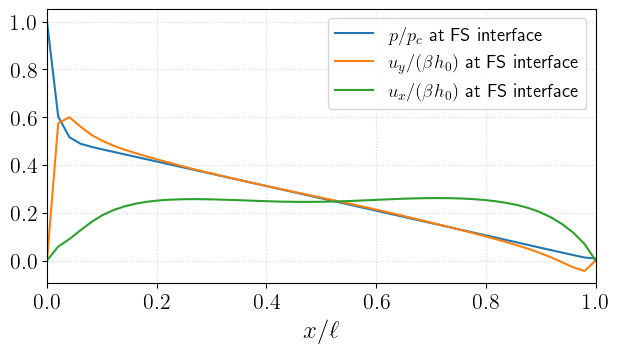

In [68]:
# Create points along the fluid-solid interface:
fs_line_points = [(x, h0) for x in x_vals]

# Evaluate the vertical displacement and pressure at each point:
u_fs_values = []
p_fs_values = []
for point in fs_line_points:
    u_fs_value = uhat(point)
    u_fs_values.append(u_fs_value)
    p_fs_value = p(point)
    p_fs_values.append(p_fs_value)

# Plotting:
fig, ax = plt.subplots()
ax.plot(x_vals/l, np.array(p_fs_values)/float(p_c), 
        label="$p/p_c$ at FS interface")
ax.plot(x_vals/l, np.array(u_fs_values)[:,1]/float(beta*h0),
        label=r"$u_y/(\beta h_0)$ at FS interface")
ax.plot(x_vals/l, np.array(u_fs_values)[:,0]/float(beta*h0),
        label=r"$u_x/(\beta h_0)$ at FS interface")
ax.set_xlabel(r"$x/\ell$")
#ax.set_ylabel()
ax.grid(alpha=0.5, linestyle='dotted')

ax.legend()

ax.set_xlim(0, 1)
#ax.set_ylim(0, pressure_rigid[0]/float(p_c))
#ax.set_yticks(np.arange(0,pressure_rigid[0]/float(p_c)+0.1,2))
#ax.set_aspect(1)
ax.set_box_aspect(1 / 2)

plt.tight_layout()
plt.show()    

## Pressure contours

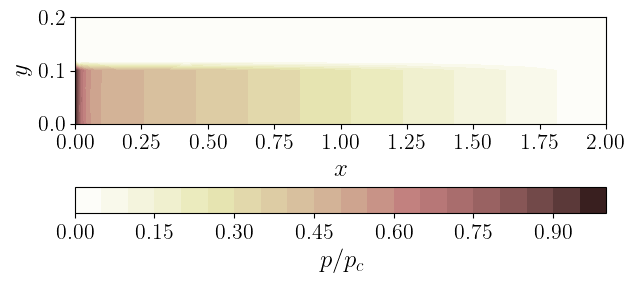

In [64]:
# Extract coordinates and velocity values
coordinates = mesh.coordinates()
cells = mesh.cells()

# Get pressure values at vertices
pressure_values = p.compute_vertex_values(mesh)

# Create triangulation and plot
triang = tri.Triangulation(coordinates[:, 0], coordinates[:, 1], cells)
fig, ax = plt.subplots()
contour = ax.tricontourf(triang, pressure_values/float(p_c), levels=20, cmap="pink_r")
fig.colorbar(contour,label="$p/p_c$",orientation='horizontal')
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

ax.set_aspect(2)

plt.tight_layout()
plt.show()

## Fluid velocity magnitude contours

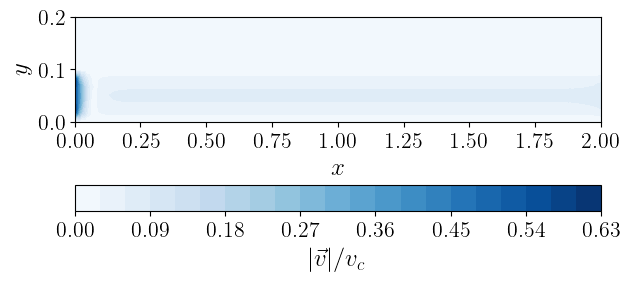

In [65]:
#(v, p) = w_old.split()

# Extract coordinates and velocity values
coordinates = mesh.coordinates()
cells = mesh.cells()
dim = mesh.geometry().dim()
num_vertices = len(coordinates)

# Get velocity values at vertices
velocity_values = v.compute_vertex_values(mesh)
velocity_values = velocity_values.reshape((dim, num_vertices)).T

# Compute magnitude
magnitude = np.linalg.norm(velocity_values, axis=1)

# Create triangulation and plot
triang = tri.Triangulation(coordinates[:, 0], coordinates[:, 1], cells)
fig, ax = plt.subplots()
contour = ax.tricontourf(triang, magnitude/float(v_c), levels=20, cmap="Blues")
fig.colorbar(contour,label=r"$|\vec{v}|/v_c$",orientation='horizontal')
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

ax.set_aspect(2)

plt.tight_layout()
plt.show()
